In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [179]:
# ------------------------------- setting start ------------------------------ #
# color
color_palette = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
errorbar_color = "#3A3A3A"

# font
csfont = {'family':'Times New Roman', 'serif': 'Times' , 'size' : 22}
plt.rc('text', usetex=True)
plt.rc('font', **csfont)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42	

# bar plot size
bar_width = 0.4
bar_btw_space = 0.04
bar_space = 0.2

# errorbar plot size
err_lw=1.5
err_capsize=4
err_capthick=1.5

# set fig size
figsize=(6.4, 4.8)

markersize=15
# -------------------------------- setting end ------------------------------- #

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


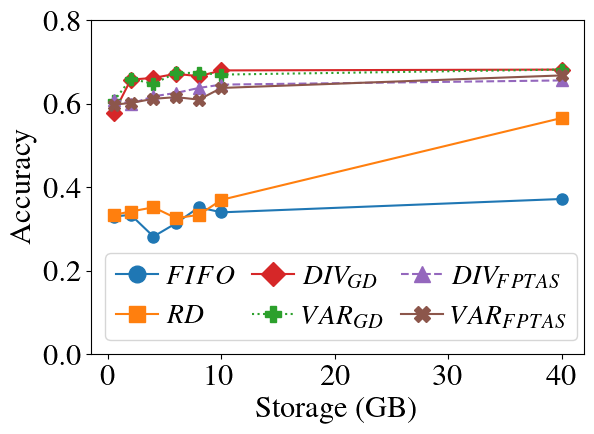

('FIFO', [0.372, 0.34, 0.352, 0.314, 0.282, 0.334, 0.33])
('RD', [0.566, 0.37, 0.334, 0.326, 0.352, 0.342, 0.334])
('DIV_GD', [0.682, 0.68, 0.666, 0.672, 0.662, 0.658, 0.578])
('VAR_GD', [0.682, 0.67, 0.674, 0.674, 0.648, 0.66, 0.606])
('DIV_FPTAS', [0.656, 0.646, 0.638, 0.626, 0.618, 0.6, 0.61])
('VAR_FPTAS', [0.668, 0.638, 0.61, 0.616, 0.612, 0.602, 0.598])


In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

groups = defaultdict(lambda: {"x": [], "y": []})

# Read file
with open("result_acc.txt", "r") as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 4:
            continue

        x = int(parts[0])
        label1 = parts[1]
        label2 = parts[2]
        y = float(parts[3])

        label = label1 if label2 == "" else f"{label1}_{label2}"
        label = label.upper()

        groups[label]["x"].append(x / 1000)
        groups[label]["y"].append(y)

plt.figure(figsize=figsize)
labels = ["FIFO", "RD", "DIV_GD", "VAR_GD", "DIV_FPTAS", "VAR_FPTAS"]
ltxs = [r"$FIFO$",r"$RD$", r"$DIV_{GD}$", r"$VAR_{GD}$", r"$DIV_{FPTAS}$", r"$VAR_{FPTAS}$"]
colors = color_palette[:len(labels)]
markers = ['o', 's', 'D', 'P', '^', 'X']
lines = ['-', '-', '-', ':', '--', '-']
# Plot lines
for i, label in enumerate(labels):
    # if label in ["DIV_APPR", "VAR_APPR"]:
    #     continue
    data = groups[label]
    # sort by x so lines look correct
    xy = sorted(zip(data["x"], data["y"]))
    x_sorted, y_sorted = zip(*xy)

    plt.plot(x_sorted, y_sorted, color=colors[i], ls=lines[i], marker=markers[i], label=ltxs[i], ms=8)

plt.xlabel("Storage (GB)")
plt.ylabel("Accuracy")
plt.ylim(0, 0.8)
# plt.title("Line Plot with Labels")
plt.legend(ncol=3, fontsize=20, markerscale=1.5, handlelength=1.5, handletextpad=0.3, columnspacing=0.6)
plt.tight_layout()
plt.savefig("result_fig/acc.eps", dpi=300)
plt.savefig("result_fig/acc.png", dpi=300)

plt.show()

result_acc = [(label, groups[label]["y"]) for label in labels]
for r in result_acc:
    print(r)

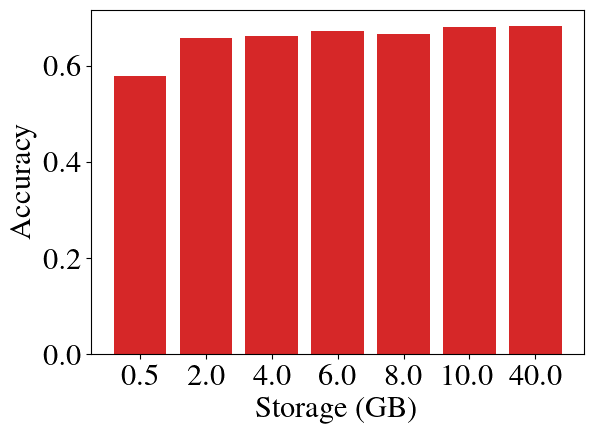

In [ ]:
plt.figure(figsize=figsize)

selected_index = 2

label=labels[selected_index]
color=colors[selected_index]
ltx=ltxs[selected_index]
data = groups[label]
xy = sorted(zip(data["x"], data["y"]))

x_sorted, y_sorted = zip(*xy)

x_pos = np.arange(len(x_sorted))
plt.bar(x_pos, y_sorted, width=0.8, color=color)
plt.xticks(x_pos, x_sorted)

plt.xlabel("Storage (GB)")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig("result_fig/acc_div_gd.eps", dpi=300)
plt.savefig("result_fig/acc_div_gd.png", dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


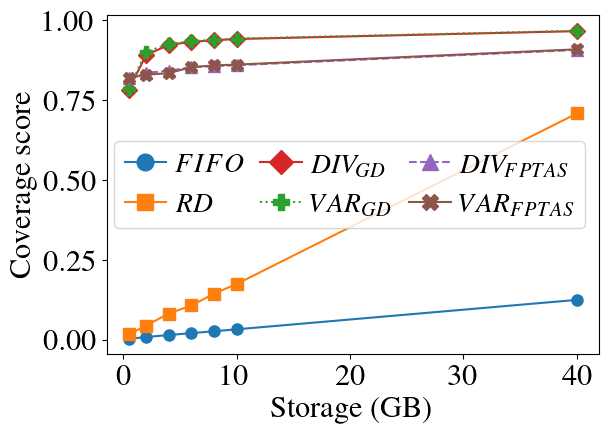

('FIFO', [0.124, 0.0319, 0.0258, 0.0199, 0.0139, 0.0078, 0.002])
('RD', [0.7072, 0.1737, 0.1434, 0.1064, 0.0812, 0.0434, 0.0162])
('DIV_GD', [0.9649, 0.9402, 0.9364, 0.9313, 0.9216, 0.8901, 0.7822])
('VAR_GD', [0.9658, 0.9415, 0.9378, 0.9329, 0.9239, 0.9003, 0.7845])
('DIV_FPTAS', [0.9061, 0.8583, 0.855, 0.8525, 0.8407, 0.8344, 0.817])
('VAR_FPTAS', [0.908, 0.8602, 0.8576, 0.8523, 0.8333, 0.8287, 0.8183])


In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

groups = defaultdict(lambda: {"x": [], "y": []})

# Read file
with open("result_cover.txt", "r") as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 4:
            continue

        x = int(parts[0])
        label1 = parts[1]
        label2 = parts[2]
        y = float(parts[3])

        label = label1 if label2 == "" else f"{label1}_{label2}"
        label = label.upper()

        groups[label]["x"].append(x / 1000)
        groups[label]["y"].append(y)

plt.figure(figsize=figsize)
labels = ["FIFO", "RD", "DIV_GD", "VAR_GD", "DIV_FPTAS", "VAR_FPTAS"]
ltxs = [r"$FIFO$",r"$RD$", r"$DIV_{GD}$", r"$VAR_{GD}$", r"$DIV_{FPTAS}$", r"$VAR_{FPTAS}$"]
colors = color_palette[:len(labels)]
markers = ['o', 's', 'D', 'P', '^', 'X']
lines = ['-', '-', '-', ':', '--', '-']
# Plot lines
for i, label in enumerate(labels):
    data = groups[label]
    # sort by x so lines look correct
    xy = sorted(zip(data["x"], data["y"]))
    x_sorted, y_sorted = zip(*xy)

    plt.plot(x_sorted, y_sorted, color=colors[i], ls=lines[i], marker=markers[i], label=ltxs[i], ms=8)

plt.xlabel("Storage (GB)")
plt.ylabel("Coverage score")

# plt.title("Line Plot with Labels")
plt.legend(ncol=3, fontsize=20, markerscale=1.5, handlelength=1.5, handletextpad=0.3, columnspacing=0.6)
plt.tight_layout()
plt.savefig("result_fig/cover.eps", dpi=300)
plt.savefig("result_fig/cover.png", dpi=300)

plt.show()

result_cover = [(label, groups[label]["y"]) for label in labels]
for r in result_cover:
    print(r)


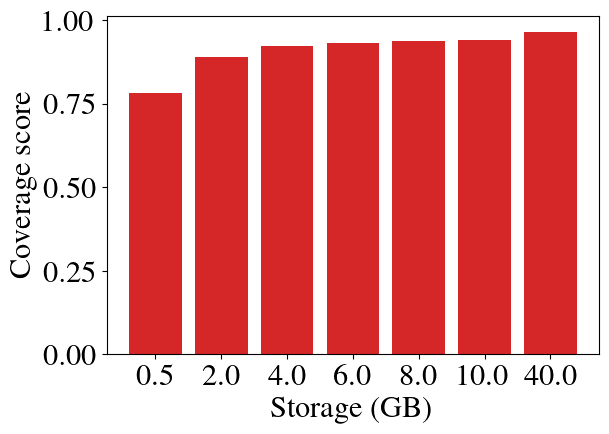

In [ ]:
plt.figure(figsize=figsize)

selected_index = 2

label=labels[selected_index]
color=colors[selected_index]
ltx=ltxs[selected_index]
data = groups[label]
xy = sorted(zip(data["x"], data["y"]))

x_sorted, y_sorted = zip(*xy)

x_pos = np.arange(len(x_sorted))
plt.bar(x_pos, y_sorted, width=0.8, color=color)
plt.xticks(x_pos, x_sorted)

plt.xlabel("Storage (GB)")
plt.ylabel("Coverage score")

plt.tight_layout()
plt.savefig("result_fig/cover_div_gd.eps", dpi=300)
plt.savefig("result_fig/cover_div_gd.png", dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FIFO 0.6553
RD 0.9769
DIV_GD 0.9799
VAR_GD 0.9558
DIV_FPTAS 0.8636
VAR_FPTAS 0.9387


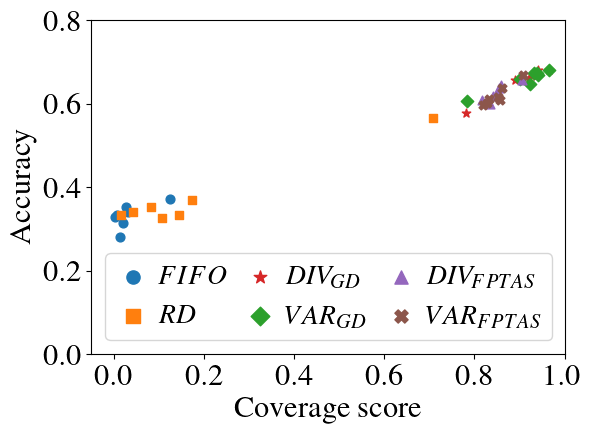

In [ ]:
from scipy.stats import pearsonr, spearmanr

plt.figure(figsize=figsize)
labels = ["FIFO", "RD", "DIV_GD", "VAR_GD", "DIV_FPTAS", "VAR_FPTAS"]
ltx = [r"$FIFO$",r"$RD$", r"$DIV_{GD}$", r"$VAR_{GD}$", r"$DIV_{FPTAS}$", r"$VAR_{FPTAS}$"]
colors = color_palette[:len(labels)]
markers = ['o', 's', '*', 'D', '^', 'X']
lines = ['-', '-', '-', ':', '--', '-']

for i, label in enumerate(labels):
    acc_list = result_acc[i][1]
    cover_list = result_cover[i][1]
    # print(list(zip(acc_list, cover_list)))
    plt.scatter(cover_list, acc_list, c=colors[i], marker=markers[i], s=40, label=ltx[i])

# global regression
all_cover = np.concatenate([result_cover[i][1] for i in range(len(result_cover))])
all_acc = np.concatenate([result_acc[i][1] for i in range(len(result_acc))])

# k, b = np.polyfit(all_cover, all_acc, 1)

# x_line = np.linspace(0, 1, 200)
# y_line = k * x_line + b

# plt.plot(x_line, y_line, ls='--', linewidth=1, color='gray')

pearson_r, pearson_p = pearsonr(all_acc, all_cover)

# print("Pearson r:", pearson_r)
# print("Pearson p-value:", pearson_p)


for i in range(len(result_cover)):
    all_cover = result_cover[i][1]
    all_acc = result_acc[i][1]
    pearson_r, _ = pearsonr(all_acc, all_cover)
    print(result_cover[i][0], f"{pearson_r:.4f}")

plt.xticks(np.linspace(0, 1, 6))
plt.yticks(np.linspace(0, 1, 6))

plt.xlabel("Coverage score")
plt.ylabel("Accuracy")
plt.ylim(0, 0.8)
plt.xlim(-0.05, 1)


# plt.title("Line Plot with Labels")
plt.legend(ncol=3, fontsize=20, markerscale=1.5, handlelength=1.2, handletextpad=0.3, columnspacing=0.6)
plt.tight_layout()
plt.savefig("result_fig/cover_acc.eps", dpi=300)
plt.savefig("result_fig/cover_acc.png", dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1.4874365 28.26293286 44.73355664 0.01969341


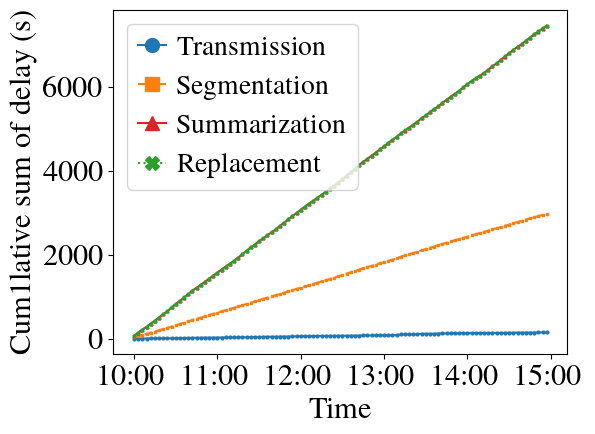

In [ ]:
trans = np.loadtxt("time_trans.txt")
seg = np.loadtxt("time_seg.txt")
cap = np.loadtxt("time_cap.txt")
rp = np.loadtxt("time_rp_gd_10000.txt")

start = 200
interval = 100

trans_select = trans[start:start+interval]
seg_select = seg[start:start+interval]
cap_select = cap[start:start+interval]
rp_select = rp[start:start+interval]
print(trans_select.mean(), seg_select.mean(), cap_select.mean(), rp_select.mean())
cum_trans = np.cumsum(trans_select)
cum_seg = cum_trans + np.cumsum(seg_select)
cum_cap = cum_seg + np.cumsum(cap_select)
cum_rp = cum_cap + np.cumsum(rp_select)

cumulative = [cum_trans, cum_seg, cum_cap, cum_rp]

labels = ["Transmission", "Segmentation", "Summarization", "Replacement"]
colors = color_palette[:len(labels)]
markers = ['o', 's', '^', 'X']
lines = ['-', '--', '-', ':']

plt.figure(figsize=figsize)
x = np.arange(interval)

for i in range(4):
    plt.plot(x, cumulative[i], color=colors[i], label=labels[i], marker=markers[i], ls=lines[i], ms=2)

from datetime import datetime, timedelta

start_time = datetime.strptime("10:00", "%H:%M")

hour_ticks = np.arange(0, interval+1, 20)   # every 20 samples = 1 hour

hour_labels = [
    (start_time + timedelta(hours=i)).strftime("%H:%M")
    for i in range(len(hour_ticks))
]

plt.xticks(hour_ticks, hour_labels)
plt.xlabel("Time")
plt.ylabel("Cum1lative sum of delay (s)")
plt.legend(fontsize=20, markerscale=5, handlelength=1.0, handletextpad=0.4, columnspacing=1.0)

plt.tight_layout()
plt.savefig("result_fig/cumsum_delay.eps", dpi=300)
plt.savefig("result_fig/cumsum_delay.png", dpi=300)
plt.show()

{'Transmission': np.float64(144.4521428), 'Segmentation': np.float64(2798.5333794), 'Summarization': np.float64(4426.2803868), 'Replacement': np.float64(1.9366032)}
{'Transmission': np.float64(15.610259648413166), 'Segmentation': np.float64(35.62918901463052), 'Summarization': np.float64(119.30840457942725), 'Replacement': np.float64(1.8928799615323408)}
7371.2025122 1.9596821897230305


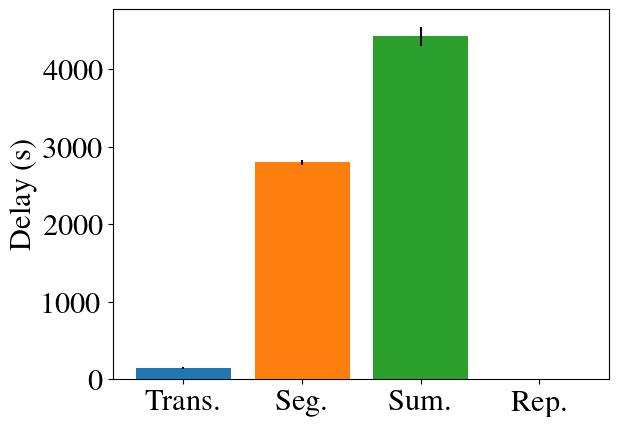

In [ ]:
import numpy as np

interval = 100

components = {
    "Transmission": trans,
    "Segmentation": seg,
    "Summarization": cap,
    "Replacement": rp,
}

daily_mean = {}
daily_yerr = {}

for name, data in components.items():
    n_days = len(data) // interval

    # Shape: (n_days, interval)
    daily = data[:n_days * interval].reshape(n_days, interval)
    
    daily_sum = data[:n_days * interval].reshape(n_days, interval).sum(axis=1)
    
    # Mean and std for each day
    # daily_mean[name] = daily.mean(axis=1)
    # daily_yerr[name] = 1.96 * daily.std(axis=1)
    daily_mean[name] = daily_sum.mean()
    daily_yerr[name] = 1.96 * daily_sum.std()

print(daily_mean)
print(daily_yerr)

total = sum(daily_mean.values())
print(total, daily_mean["Transmission"] / total *100)
plt.figure(figsize=figsize)
keys = ["Transmission", "Segmentation", "Summarization", "Replacement"]

x = np.arange(len(keys))
for i, k in enumerate(keys):
    plt.bar(x[i], daily_mean[k], yerr=daily_yerr[k], width=0.8)

plt.ylabel("Delay (s)")
plt.xticks(x, ["Trans.", "Seg.", "Sum.", "Rep."], ha="center")
plt.savefig("result_fig/delay_day.eps", dpi=300)
plt.savefig("result_fig/delay_day.png", dpi=300)
plt.show()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


$GD_{40}$ 0.02926
$GD_{10}$ 0.01937
$GD_{0.5}$ 0.00418
$FPTAS_{40}$ 7.92445
$FPTAS_{10}$ 3.17771
$FPTAS_{0.5}$ 0.98871


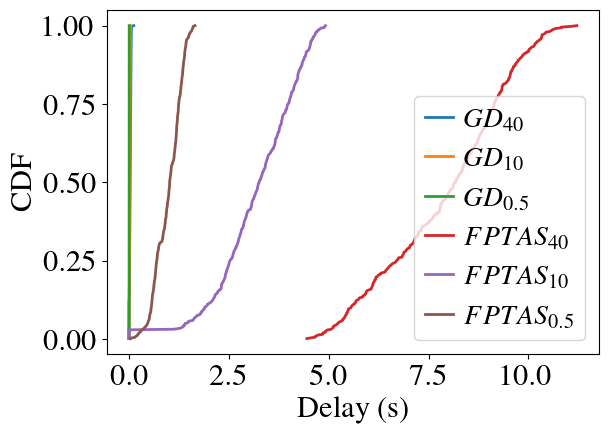

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

files = {
    r"$GD_{40}$": "time_rp_gd_40000.txt",
    r"$GD_{10}$": "time_rp_gd_10000.txt",
    r"$GD_{0.5}$": "time_rp_gd_500.txt",
    r"$FPTAS_{40}$": "time_rp_fptas_40000.txt",
    r"$FPTAS_{10}$": "time_rp_fptas_10000.txt",
    r"$FPTAS_{0.5}$": "time_rp_fptas_500.txt",

}

plt.figure(figsize=figsize)

for label, filename in files.items():
    data = np.loadtxt(filename)
    print(label, round(data.mean(), 5))
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label, lw=2)

# plt.xscale("log")

plt.xlabel("Delay (s)")
plt.ylabel("CDF")
plt.legend(fontsize=20, markerscale=1.5, handletextpad=0.4, columnspacing=1.0, handlelength=1.0)
plt.tight_layout()
plt.savefig("result_fig/delay_rp.eps", dpi=300)
plt.savefig("result_fig/delay_rp.png", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


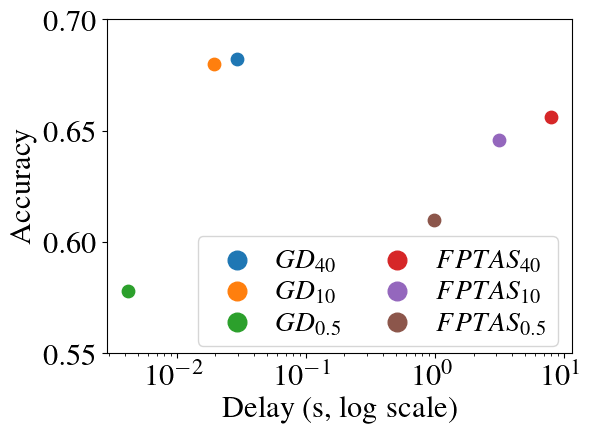

In [ ]:
import matplotlib.pyplot as plt
methods = files.keys()
accuracy = [
    0.682, 0.680, 0.578,
    0.656, 0.646, 0.610
]
delay = [
    0.02926, 0.01937, 0.00418,
    7.92445, 3.17771, 0.98871
]

plt.figure(figsize=figsize)

for i, label in enumerate(methods):
    plt.scatter(delay[i], accuracy[i], s=80, label=label)

plt.xscale("log")
plt.ylim(0.55, 0.7)
plt.yticks([0.55, 0.60, 0.65, 0.70])
plt.xlabel("Delay (s, log scale)")
plt.ylabel("Accuracy")
plt.legend(
    ncol=2,
    fontsize=20,
    markerscale=1.5,
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=0.2,
    loc="lower right",
    bbox_to_anchor=(1, -0.02)  # shift slightly down
)
plt.tight_layout()

plt.savefig("result_fig/delay_acc.eps", dpi=300)
plt.savefig("result_fig/delay_acc.png", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


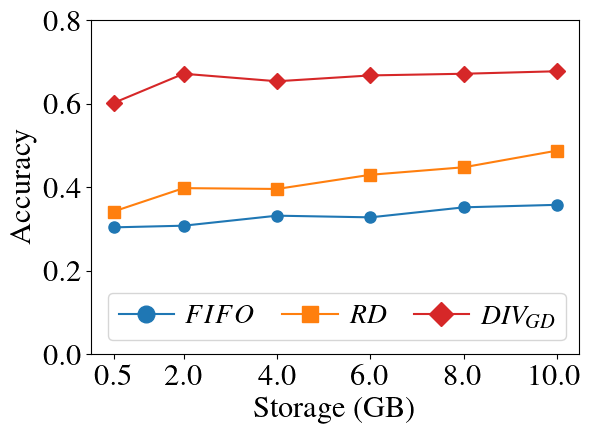

('FIFO', [0.358, 0.352, 0.328, 0.332, 0.308, 0.304])
('RD', [0.488, 0.448, 0.43, 0.396, 0.398, 0.342])
('DIV_GD', [0.678, 0.672, 0.668, 0.654, 0.672, 0.602])


In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

groups = defaultdict(lambda: {"x": [], "y": []})

# Read file
with open("result_comb_nw.txt", "r") as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 4:
            continue

        x = int(parts[0])
        label1 = parts[1]
        label2 = parts[2]
        y = float(parts[3])

        label = label1 if label2 == "" else f"{label1}_{label2}"
        label = label.upper()

        groups[label]["x"].append(x / 1000)
        groups[label]["y"].append(y)

plt.figure(figsize=figsize)
labels = ["FIFO", "RD", "DIV_GD"]
ltxs = [r"$FIFO$",r"$RD$", r"$DIV_{GD}$"]
colors = color_palette[:len(labels)]
markers = ['o', 's', 'D', 'P', '^', 'X']
lines = ['-', '-', '-', ':', '--', '-']
# Plot lines
for i, label in enumerate(labels):
    # if label in ["DIV_APPR", "VAR_APPR"]:
    #     continue
    data = groups[label]
    # sort by x so lines look correct
    xy = sorted(zip(data["x"], data["y"]))
    x_sorted, y_sorted = zip(*xy)

    plt.plot(x_sorted, y_sorted, color=colors[i], ls=lines[i], marker=markers[i], label=ltxs[i], ms=8)

plt.xlabel("Storage (GB)")
plt.ylabel("Accuracy")
plt.ylim(0, 0.8)
plt.xticks(x_sorted)
# plt.title("Line Plot with Labels")
plt.legend(ncol=3, fontsize=20, markerscale=1.5, handletextpad=0.4, columnspacing=1.0, loc="lower right")
plt.tight_layout()
plt.savefig("result_fig/acc_nw.eps", dpi=300)
plt.savefig("result_fig/acc_nw.png", dpi=300)

plt.show()

result_acc = [(label, groups[label]["y"]) for label in labels]
for r in result_acc:
    print(r)